In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os

# Find all CSV files available in the Kaggle input directory
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/kaggle/input/datasets/artemkabseu/financial-transactions-dataset-expenses-and-income/Expenses_clean.csv
/kaggle/input/datasets/artemkabseu/financial-transactions-dataset-expenses-and-income/Income_clean.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/artemkabseu/financial-transactions-dataset-expenses-and-income/Expenses_clean.csv')

print(df.head())
print(df.columns)

             date_time          category account  amount currency   tags
0  2025-11-30 00:00:00            Health  acct_1   114.0      BYN  tag_1
1  2025-11-29 00:00:00              Food  acct_1     5.0      BYN  tag_1
2  2025-11-27 00:00:00  Public transport  acct_2     1.0      BYN  tag_1
3  2025-11-27 00:00:00              Cafe  acct_1    10.0      BYN  tag_1
4  2025-11-27 00:00:00  Public transport  acct_2     1.0      BYN  tag_1
Index(['date_time', 'category', 'account', 'amount', 'currency', 'tags'], dtype='object')


In [4]:
# Convert date_time to datetime format
df['date_time'] = pd.to_datetime(df['date_time'])

# Check the date range of our data
print("Data starts from:", df['date_time'].min())
print("Data ends on:", df['date_time'].max())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

Data starts from: 2025-01-07 00:00:00
Data ends on: 2025-11-30 00:00:00

Missing values:
date_time    0
category     0
account      0
amount       0
currency     0
tags         0
dtype: int64


In [5]:
# ============================================
# STEP 1: PREPARE WEEKLY SPENDING DATA
# ============================================

# Make sure date_time is in proper datetime format
df['date_time'] = pd.to_datetime(df['date_time'])

# Sort transactions by date
df = df.sort_values('date_time')

# Create a week column
# W-SUN means the week runs from Monday to Sunday
df['week'] = df['date_time'].dt.to_period('W-SUN')

# Calculate total spending for each week
weekly_spending = (
    df.groupby('week')['amount']
      .sum()
      .reset_index()
)

# Convert the week period into a timestamp
weekly_spending['week_start'] = weekly_spending['week'].dt.start_time

# Remove the original week column
weekly_spending = weekly_spending.drop(columns=['week'])

# Display the first few weeks
print("Weekly Spending Data:")
print(weekly_spending.head(10))

print("\nTotal number of weeks:", len(weekly_spending))

Weekly Spending Data:
   amount week_start
0   112.0 2025-01-06
1   298.0 2025-01-13
2   385.0 2025-01-20
3   189.0 2025-01-27
4   261.0 2025-02-03
5    44.0 2025-02-10
6   277.0 2025-02-17
7    58.0 2025-02-24
8  2540.0 2025-03-03
9   285.0 2025-03-10

Total number of weeks: 47


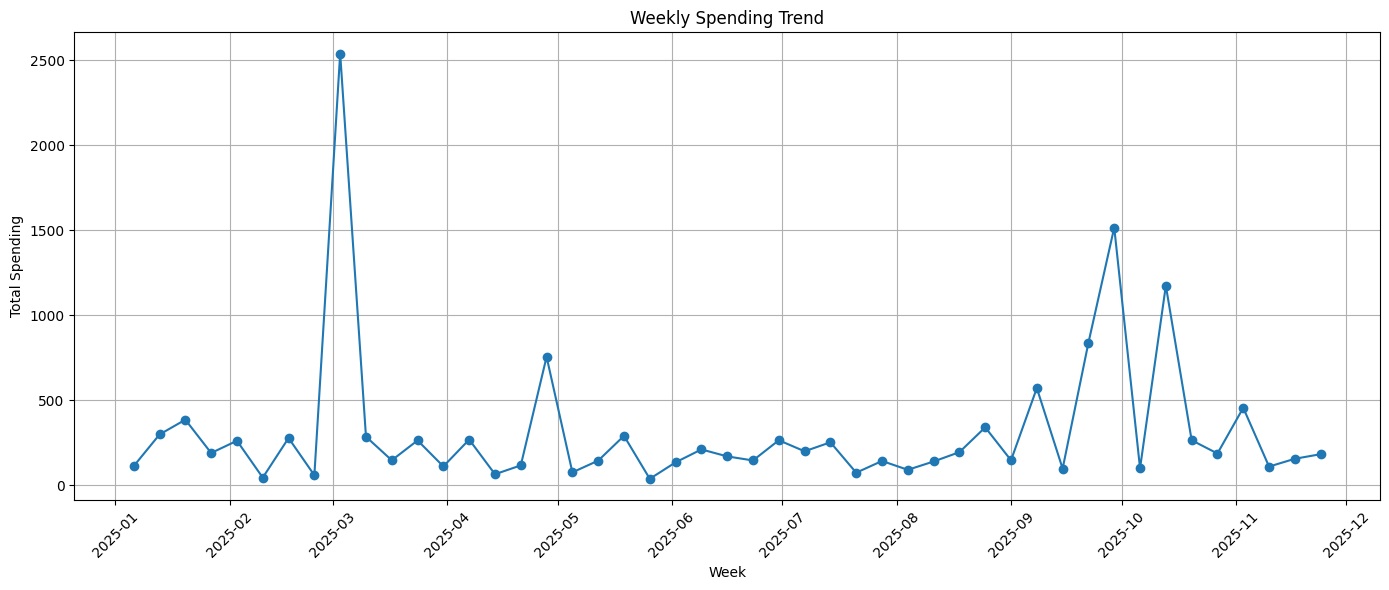

In [6]:
# ============================================
# STEP 2: VISUALIZE WEEKLY SPENDING
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    weekly_spending['week_start'],
    weekly_spending['amount'],
    marker='o'
)

plt.title('Weekly Spending Trend')
plt.xlabel('Week')
plt.ylabel('Total Spending')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# STEP 5: CREATE WEEKLY SPENDING DATA
# ============================================================

print("Creating weekly spending data...")

# Make sure date_time is in datetime format
df['date_time'] = pd.to_datetime(df['date_time'])

# Create a week column
# W-SUN means the week runs from Monday to Sunday
df['week'] = df['date_time'].dt.to_period('W-SUN')

# Calculate total spending for each week
weekly_spending = (
    df.groupby('week')['amount']
      .sum()
      .reset_index()
)

# Convert the week period into a normal date
weekly_spending['week_start'] = weekly_spending['week'].apply(
    lambda x: x.start_time
)

# Sort chronologically
weekly_spending = weekly_spending.sort_values('week_start').reset_index(drop=True)

print("Weekly spending created successfully!")
print("\nFirst few weeks:")
print(weekly_spending.head())

Creating weekly spending data...
Weekly spending created successfully!

First few weeks:
                    week  amount week_start
0  2025-01-06/2025-01-12   112.0 2025-01-06
1  2025-01-13/2025-01-19   298.0 2025-01-13
2  2025-01-20/2025-01-26   385.0 2025-01-20
3  2025-01-27/2025-02-02   189.0 2025-01-27
4  2025-02-03/2025-02-09   261.0 2025-02-03


In [10]:
# ============================================================
# STEP 6: RUNNING WEEK-ON-WEEK COMPARISON
# ============================================================

print("\nCreating week-on-week comparisons...")

# Previous week's spending
weekly_spending['previous_week_spending'] = (
    weekly_spending['amount'].shift(1)
)

# Absolute change from previous week
weekly_spending['change_amount'] = (
    weekly_spending['amount']
    - weekly_spending['previous_week_spending']
)

# Percentage change from previous week
weekly_spending['change_percentage'] = (
    weekly_spending['change_amount']
    / weekly_spending['previous_week_spending']
) * 100

# Display the results
print("\nRunning Week-on-Week Comparison:")
print(
    weekly_spending[
        [
            'week_start',
            'amount',
            'previous_week_spending',
            'change_amount',
            'change_percentage'
        ]
    ].to_string(index=False)
)


Creating week-on-week comparisons...

Running Week-on-Week Comparison:
week_start  amount  previous_week_spending  change_amount  change_percentage
2025-01-06   112.0                     NaN            NaN                NaN
2025-01-13   298.0                   112.0          186.0         166.071429
2025-01-20   385.0                   298.0           87.0          29.194631
2025-01-27   189.0                   385.0         -196.0         -50.909091
2025-02-03   261.0                   189.0           72.0          38.095238
2025-02-10    44.0                   261.0         -217.0         -83.141762
2025-02-17   277.0                    44.0          233.0         529.545455
2025-02-24    58.0                   277.0         -219.0         -79.061372
2025-03-03  2540.0                    58.0         2482.0        4279.310345
2025-03-10   285.0                  2540.0        -2255.0         -88.779528
2025-03-17   146.0                   285.0         -139.0         -48.771930
2025

In [11]:
# ============================================================
# STEP 7: CALCULATE 4-WEEK RUNNING AVERAGE
# ============================================================

print("\nCalculating 4-week running average...")

weekly_spending['4_week_average'] = (
    weekly_spending['amount']
    .rolling(window=4)
    .mean()
)

print("\nWeekly spending with 4-week average:")
print(
    weekly_spending[
        [
            'week_start',
            'amount',
            'previous_week_spending',
            'change_percentage',
            '4_week_average'
        ]
    ].tail(10).to_string(index=False)
)


Calculating 4-week running average...

Weekly spending with 4-week average:
week_start  amount  previous_week_spending  change_percentage  4_week_average
2025-09-22   838.0                    97.0         763.917526          413.00
2025-09-29  1516.0                   838.0          80.906921          755.50
2025-10-06    99.0                  1516.0         -93.469657          637.50
2025-10-13  1174.0                    99.0        1085.858586          906.75
2025-10-20   264.0                  1174.0         -77.512777          763.25
2025-10-27   186.0                   264.0         -29.545455          430.75
2025-11-03   455.0                   186.0         144.623656          519.75
2025-11-10   109.0                   455.0         -76.043956          253.50
2025-11-17   155.0                   109.0          42.201835          226.25
2025-11-24   182.0                   155.0          17.419355          225.25


In [12]:
# ============================================================
# STEP 8: IDENTIFY WEEKLY SPENDING TREND
# ============================================================

def get_spending_status(row):

    if pd.isna(row['change_percentage']):
        return "No previous week available"

    if row['change_percentage'] > 10:
        return "Spending increased significantly"

    elif row['change_percentage'] > 0:
        return "Spending increased"

    elif row['change_percentage'] < -10:
        return "Spending decreased significantly"

    elif row['change_percentage'] < 0:
        return "Spending decreased"

    else:
        return "Spending remained stable"


weekly_spending['spending_status'] = (
    weekly_spending.apply(get_spending_status, axis=1)
)

print("\nWeekly spending trends:")
print(
    weekly_spending[
        [
            'week_start',
            'amount',
            'change_percentage',
            '4_week_average',
            'spending_status'
        ]
    ].tail(10).to_string(index=False)
)


Weekly spending trends:
week_start  amount  change_percentage  4_week_average                  spending_status
2025-09-22   838.0         763.917526          413.00 Spending increased significantly
2025-09-29  1516.0          80.906921          755.50 Spending increased significantly
2025-10-06    99.0         -93.469657          637.50 Spending decreased significantly
2025-10-13  1174.0        1085.858586          906.75 Spending increased significantly
2025-10-20   264.0         -77.512777          763.25 Spending decreased significantly
2025-10-27   186.0         -29.545455          430.75 Spending decreased significantly
2025-11-03   455.0         144.623656          519.75 Spending increased significantly
2025-11-10   109.0         -76.043956          253.50 Spending decreased significantly
2025-11-17   155.0          42.201835          226.25 Spending increased significantly
2025-11-24   182.0          17.419355          225.25 Spending increased significantly


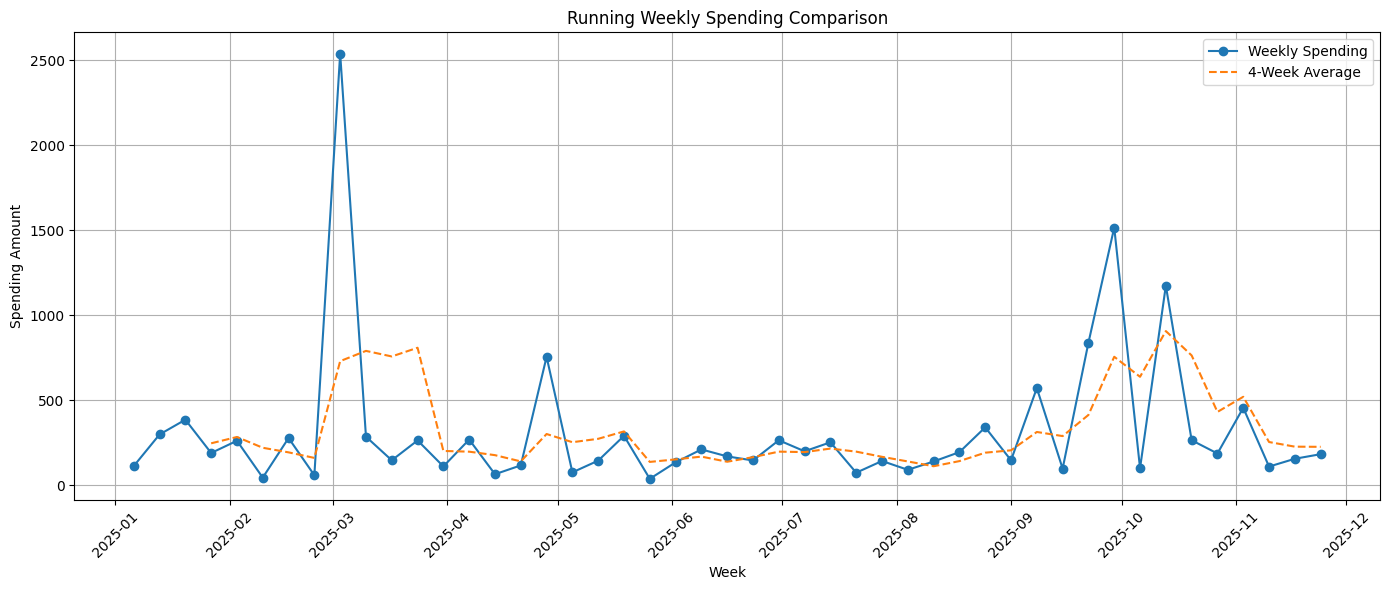

In [13]:
# ============================================================
# STEP 9: VISUALIZE WEEKLY SPENDING
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    weekly_spending['week_start'],
    weekly_spending['amount'],
    marker='o',
    label='Weekly Spending'
)

plt.plot(
    weekly_spending['week_start'],
    weekly_spending['4_week_average'],
    linestyle='--',
    label='4-Week Average'
)

plt.xlabel('Week')
plt.ylabel('Spending Amount')
plt.title('Running Weekly Spending Comparison')

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# STEP 10: FINAL WEEKLY SPENDING TABLE
# ============================================================

weekly_comparison = weekly_spending[
    [
        'week_start',
        'amount',
        'previous_week_spending',
        'change_amount',
        'change_percentage',
        '4_week_average',
        'spending_status'
    ]
].copy()

# Rename columns to make them easier to understand
weekly_comparison.columns = [
    'Week',
    'Current_Week_Spending',
    'Previous_Week_Spending',
    'Change_Amount',
    'Change_Percentage',
    'Four_Week_Average',
    'Spending_Status'
]

print("\n==========================================")
print("FINAL RUNNING WEEKLY COMPARISON")
print("==========================================")

print(
    weekly_comparison.to_string(index=False)
)


FINAL RUNNING WEEKLY COMPARISON
      Week  Current_Week_Spending  Previous_Week_Spending  Change_Amount  Change_Percentage  Four_Week_Average                  Spending_Status
2025-01-06                  112.0                     NaN            NaN                NaN                NaN       No previous week available
2025-01-13                  298.0                   112.0          186.0         166.071429                NaN Spending increased significantly
2025-01-20                  385.0                   298.0           87.0          29.194631                NaN Spending increased significantly
2025-01-27                  189.0                   385.0         -196.0         -50.909091             246.00 Spending decreased significantly
2025-02-03                  261.0                   189.0           72.0          38.095238             283.25 Spending increased significantly
2025-02-10                   44.0                   261.0         -217.0         -83.141762            

In [15]:
# ============================================================
# STEP 6: PREPARE WEEKLY DATA FOR ML
# ============================================================

print("Preparing weekly spending data for ML...")

# Make a copy so that we don't accidentally modify our original table
ml_data = weekly_comparison.copy()

# Keep only the columns we need
ml_data = ml_data[['Week', 'Current_Week_Spending']].copy()

# Make sure Week is treated as a date
ml_data['Week'] = pd.to_datetime(ml_data['Week'])

# Sort weeks chronologically
ml_data = ml_data.sort_values('Week').reset_index(drop=True)

# Rename spending column to make the ML work easier to understand
ml_data = ml_data.rename(
    columns={'Current_Week_Spending': 'Weekly_Spending'}
)

print("\nWeekly spending data:")
print(ml_data.head(10))

print("\nTotal number of weeks:", len(ml_data))

Preparing weekly spending data for ML...

Weekly spending data:
        Week  Weekly_Spending
0 2025-01-06            112.0
1 2025-01-13            298.0
2 2025-01-20            385.0
3 2025-01-27            189.0
4 2025-02-03            261.0
5 2025-02-10             44.0
6 2025-02-17            277.0
7 2025-02-24             58.0
8 2025-03-03           2540.0
9 2025-03-10            285.0

Total number of weeks: 47


In [16]:
# ============================================================
# STEP 8: CREATE TRAINING DATASET
# ============================================================

print("Preparing final training dataset...")

features = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_4',
    'Rolling_4_Week_Average'
]

target = 'Weekly_Spending'

# Remove rows where historical features are not available
model_data = ml_data.dropna().copy()

print("\nFinal ML dataset:")
print(model_data.head())

print("\nNumber of usable weeks for ML:", len(model_data))

Preparing final training dataset...

Final ML dataset:
        Week  Weekly_Spending
0 2025-01-06            112.0
1 2025-01-13            298.0
2 2025-01-20            385.0
3 2025-01-27            189.0
4 2025-02-03            261.0

Number of usable weeks for ML: 47


In [18]:
# ============================================================
# STEP 7 & 8: CREATE ML FEATURES AND TRAINING DATA
# ============================================================

print("Creating ML features from running weekly spending...")

# Start from the running weekly comparison table
ml_data = weekly_comparison[['Week', 'Current_Week_Spending']].copy()

# Make sure the data is sorted chronologically
ml_data['Week'] = pd.to_datetime(ml_data['Week'])
ml_data = ml_data.sort_values('Week').reset_index(drop=True)

# Rename spending column
ml_data = ml_data.rename(
    columns={'Current_Week_Spending': 'Weekly_Spending'}
)

# ------------------------------------------------------------
# Create previous-week spending features
# ------------------------------------------------------------

ml_data['Lag_1'] = ml_data['Weekly_Spending'].shift(1)
ml_data['Lag_2'] = ml_data['Weekly_Spending'].shift(2)
ml_data['Lag_3'] = ml_data['Weekly_Spending'].shift(3)
ml_data['Lag_4'] = ml_data['Weekly_Spending'].shift(4)

# Average spending of the previous 4 weeks
ml_data['Rolling_4_Week_Average'] = (
    ml_data['Weekly_Spending']
    .shift(1)
    .rolling(window=4)
    .mean()
)

# ------------------------------------------------------------
# Remove rows where 4 weeks of history are not available
# ------------------------------------------------------------

model_data = ml_data.dropna().reset_index(drop=True)

# ------------------------------------------------------------
# Define ML features and target
# ------------------------------------------------------------

features = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_4',
    'Rolling_4_Week_Average'
]

target = 'Weekly_Spending'

print("\n==========================================")
print("ML DATA PREPARED SUCCESSFULLY")
print("==========================================")

print("\nFeatures used by the model:")
print(features)

print("\nTarget:")
print(target)

print("\nNumber of usable weeks:", len(model_data))

print("\nSample ML dataset:")
print(model_data.head(10).to_string(index=False))

Creating ML features from running weekly spending...

ML DATA PREPARED SUCCESSFULLY

Features used by the model:
['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Rolling_4_Week_Average']

Target:
Weekly_Spending

Number of usable weeks: 43

Sample ML dataset:
      Week  Weekly_Spending  Lag_1  Lag_2  Lag_3  Lag_4  Rolling_4_Week_Average
2025-02-03            261.0  189.0  385.0  298.0  112.0                  246.00
2025-02-10             44.0  261.0  189.0  385.0  298.0                  283.25
2025-02-17            277.0   44.0  261.0  189.0  385.0                  219.75
2025-02-24             58.0  277.0   44.0  261.0  189.0                  192.75
2025-03-03           2540.0   58.0  277.0   44.0  261.0                  160.00
2025-03-10            285.0 2540.0   58.0  277.0   44.0                  729.75
2025-03-17            146.0  285.0 2540.0   58.0  277.0                  790.00
2025-03-24            263.0  146.0  285.0 2540.0   58.0                  757.25
2025-03-31            110.0  26

In [20]:
# ============================================================
# STEP 6 + 7: PREPARE ML DATA AND SPLIT INTO TRAIN/TEST
# ============================================================

print("Preparing data for the ML model...")

# Features used to predict weekly spending
features = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_4',
    'Rolling_4_Week_Average'
]

# Target variable
target = 'Weekly_Spending'

# Create input features (X) and target (y)
X = model_data[features].copy()
y = model_data[target].copy()

print("\nFeatures:")
print(features)

print("\nTarget:")
print(target)

print("\nTotal usable observations:", len(model_data))


# ============================================================
# TIME-BASED TRAIN / TEST SPLIT
# ============================================================

print("\nSplitting historical data into training and testing sets...")

# Use 80% older data for training
# Use 20% more recent data for testing
split_index = int(len(model_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


# ============================================================
# DISPLAY SPLIT INFORMATION
# ============================================================

print("\n================ ML DATA SPLIT ================")

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(
    model_data['Week'].iloc[0],
    "to",
    model_data['Week'].iloc[split_index - 1]
)

print("\nTesting period:")
print(
    model_data['Week'].iloc[split_index],
    "to",
    model_data['Week'].iloc[-1]
)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nML data preparation completed successfully!")
print("================================================")

Preparing data for the ML model...

Features:
['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Rolling_4_Week_Average']

Target:
Weekly_Spending

Total usable observations: 43

Splitting historical data into training and testing sets...

================ ML DATA SPLIT ================
Training observations: 34
Testing observations: 9

Training period:
2025-02-03 00:00:00 to 2025-09-22 00:00:00

Testing period:
2025-09-29 00:00:00 to 2025-11-24 00:00:00

X_train shape: (34, 5)
X_test shape: (9, 5)

ML data preparation completed successfully!


In [21]:
# ============================================================
# STEP 8: TRAIN THE ML MODEL
# ============================================================

from sklearn.ensemble import RandomForestRegressor

print("Training the Random Forest model...")

# Create the Random Forest regression model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# Train the model using historical training data
model.fit(X_train, y_train)

print("\n================================================")
print("ML MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("================================================")

print("\nModel: Random Forest Regressor")
print("Number of trees:", 200)
print("Training observations:", len(X_train))
print("Features used:", len(features))

Training the Random Forest model...

ML MODEL TRAINING COMPLETED SUCCESSFULLY!

Model: Random Forest Regressor
Number of trees: 200
Training observations: 34
Features used: 5


In [22]:
# ============================================================
# STEP 9: EVALUATE THE ML MODEL
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Testing the model on unseen historical data...")

# Predict spending for the testing period
y_pred = model.predict(X_test)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n================================================")
print("             MODEL PERFORMANCE")
print("================================================")

print(f"Mean Absolute Error (MAE)  : ₹{mae:.2f}")
print(f"Root Mean Squared Error    : ₹{rmse:.2f}")
print(f"R² Score                   : {r2:.2f}")

print("================================================")

print("\nInterpretation:")
print(f"On average, the model's prediction differs from")
print(f"actual weekly spending by approximately ₹{mae:.2f}.")

Testing the model on unseen historical data...

             MODEL PERFORMANCE
Mean Absolute Error (MAE)  : ₹345.43
Root Mean Squared Error    : ₹553.37
R² Score                   : -0.27

Interpretation:
On average, the model's prediction differs from
actual weekly spending by approximately ₹345.43.


In [23]:
# ============================================================
# STEP 8: PREDICT NEXT WEEK'S SPENDING
# ============================================================

print("\n" + "="*60)
print("NEXT WEEK SPENDING PREDICTION")
print("="*60)

# Get the most recent historical weeks
recent_data = model_data.sort_values('Week').tail(4).copy()

print("\nRecent 4 weeks of spending:")
print(recent_data[['Week', 'Weekly_Spending']].to_string(index=False))

# ------------------------------------------------------------
# Create features for predicting the NEXT week
# ------------------------------------------------------------

# Most recent 4 weekly spending values
lag_1 = recent_data['Weekly_Spending'].iloc[-1]
lag_2 = recent_data['Weekly_Spending'].iloc[-2]
lag_3 = recent_data['Weekly_Spending'].iloc[-3]
lag_4 = recent_data['Weekly_Spending'].iloc[-4]

# Average spending over the most recent 4 weeks
rolling_average = recent_data['Weekly_Spending'].mean()

# Create input for the ML model
next_week_features = pd.DataFrame({
    'Lag_1': [lag_1],
    'Lag_2': [lag_2],
    'Lag_3': [lag_3],
    'Lag_4': [lag_4],
    'Rolling_4_Week_Average': [rolling_average]
})

print("\nFeatures used by the model:")
print(next_week_features)

# ------------------------------------------------------------
# Predict next week's spending
# ------------------------------------------------------------

predicted_spending = model.predict(next_week_features)[0]

# Make sure prediction cannot be negative
predicted_spending = max(0, predicted_spending)

print("\n----------------------------------------")
print(f"Predicted spending for next week: ₹{predicted_spending:.2f}")
print("----------------------------------------")


NEXT WEEK SPENDING PREDICTION

Recent 4 weeks of spending:
      Week  Weekly_Spending
2025-11-03            455.0
2025-11-10            109.0
2025-11-17            155.0
2025-11-24            182.0

Features used by the model:
   Lag_1  Lag_2  Lag_3  Lag_4  Rolling_4_Week_Average
0  182.0  155.0  109.0  455.0                  225.25

----------------------------------------
Predicted spending for next week: ₹268.58
----------------------------------------


In [24]:
# ============================================================
# STEP 9: RECOMMENDED SPENDING LIMIT
# ============================================================

print("\n" + "="*60)
print("RECOMMENDED SPENDING LIMIT")
print("="*60)

# Recent 4-week average
recent_average = recent_data['Weekly_Spending'].mean()

# Compare predicted spending with recent behaviour
if predicted_spending > recent_average:
    # If prediction is higher than normal spending,
    # recommend a slightly more controlled amount.
    recommended_amount = (
        recent_average + 
        0.5 * (predicted_spending - recent_average)
    )
else:
    # If prediction is already below the recent average,
    # use the prediction as the recommended target.
    recommended_amount = predicted_spending

# Round to nearest ₹10
recommended_amount = round(recommended_amount / 10) * 10

print(f"\nRecent 4-week average : ₹{recent_average:.2f}")
print(f"Predicted spending   : ₹{predicted_spending:.2f}")
print(f"Recommended limit    : ₹{recommended_amount:.0f}")

print("\n💡 Recommendation:")
print(
    f"Try to keep your spending around "
    f"₹{recommended_amount:.0f} next week."
)


RECOMMENDED SPENDING LIMIT

Recent 4-week average : ₹225.25
Predicted spending   : ₹268.58
Recommended limit    : ₹250

💡 Recommendation:
Try to keep your spending around ₹250 next week.


In [25]:
# ============================================================
# STEP 10: SPENDING TREND ANALYSIS
# ============================================================

print("\n" + "="*60)
print("SPENDING TREND ANALYSIS")
print("="*60)

# Compare latest week with previous week
latest_spending = recent_data['Weekly_Spending'].iloc[-1]
previous_spending = recent_data['Weekly_Spending'].iloc[-2]

change = latest_spending - previous_spending

if previous_spending != 0:
    change_percentage = (change / previous_spending) * 100
else:
    change_percentage = 0

print(f"\nLatest week spending   : ₹{latest_spending:.2f}")
print(f"Previous week spending : ₹{previous_spending:.2f}")
print(f"Week-on-week change    : {change_percentage:.1f}%")

if change > 0:
    print("\n📈 Your spending increased compared with last week.")
elif change < 0:
    print("\n📉 Your spending decreased compared with last week.")
else:
    print("\n➡️ Your spending remained almost unchanged.")


SPENDING TREND ANALYSIS

Latest week spending   : ₹182.00
Previous week spending : ₹155.00
Week-on-week change    : 17.4%

📈 Your spending increased compared with last week.


In [26]:
# ============================================================
# STEP 12: WEEKLY SPENDING DASHBOARD
# ============================================================

print("\n")
print("="*65)
print("                 SMART SPENDING ASSISTANT")
print("="*65)

print(f"\n📊 Recent 4-Week Average       : ₹{recent_average:.0f}")

print(f"🔮 Predicted Next-Week Spend   : ₹{predicted_spending:.0f}")

print(f"🎯 Recommended Spending Limit  : ₹{recommended_amount:.0f}")

print(f"📈 Last Week Spending          : ₹{latest_spending:.0f}")

print(f"📅 Previous Week Spending      : ₹{previous_spending:.0f}")

print("\n" + "-"*65)

if latest_spending > previous_spending:
    print("Trend: 📈 Spending increased")
elif latest_spending < previous_spending:
    print("Trend: 📉 Spending decreased")
else:
    print("Trend: ➡️ Spending remained stable")

print("-"*65)

print("\n💡 SMART INSIGHT")

if predicted_spending > recent_average:
    print(
        f"Your spending is expected to be higher next week."
    )
    print(
        f"Try to keep your spending close to "
        f"₹{recommended_amount:.0f}."
    )
else:
    print(
        f"Your spending is expected to remain controlled "
        f"next week."
    )
    print(
        f"A target of ₹{recommended_amount:.0f} "
        f"would be reasonable."
    )

print("\n" + "="*65)



                 SMART SPENDING ASSISTANT

📊 Recent 4-Week Average       : ₹225
🔮 Predicted Next-Week Spend   : ₹269
🎯 Recommended Spending Limit  : ₹250
📈 Last Week Spending          : ₹182
📅 Previous Week Spending      : ₹155

-----------------------------------------------------------------
Trend: 📈 Spending increased
-----------------------------------------------------------------

💡 SMART INSIGHT
Your spending is expected to be higher next week.
Try to keep your spending close to ₹250.

